# Simple Linear Regression

Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

Generating Data

In [ ]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)
data = pd.DataFrame({'X': X.flatten(), 'y': y})


EDA

In [ ]:
data.shape

(100, 2)

In [ ]:
print("X")
data['X'].head()
print()
data['X'].info()
print()
data['X'].describe()

print("\ny")
print(data['y'].head())
print()
data['y'].info()
print()
data['y'].describe()

X

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: X
Non-Null Count  Dtype  
--------------  -----  
100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes


y
0    50.779929
1   -10.065270
2   -34.918392
3    10.526743
4   -17.738377
Name: y, dtype: float64

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: y
Non-Null Count  Dtype  
--------------  -----  
100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes



count    100.000000
mean      -3.449530
std       41.321720
min     -118.027454
25%      -30.170786
50%       -0.634702
75%       23.478589
max       89.033145
Name: y, dtype: float64

In [ ]:
data['X'].isnull().sum(), data['y'].isnull().sum()

(np.int64(0), np.int64(0))

Visualization

<Axes: xlabel='X', ylabel='y'>

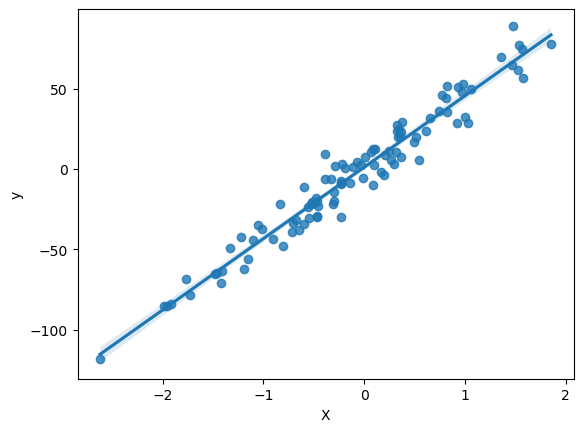

In [ ]:
sns.regplot(x=data['X'], y=data['y'])

Model (Class)

In [ ]:
class LinearRegression:
    def __init__(self, X, y, intercept: bool = True):
        self.X = np.array(X)
        self.y = np.array(y)
        self.intercept_flag = intercept
        self.slope = None
        self.intercept = None

    def fit(self):
        x_mean = np.mean(self.X)
        y_mean = np.mean(self.y)
        
        # Compute Slope (b1)
        numerator = np.sum((self.X - x_mean) * (self.y - y_mean))
        denominator = np.sum((self.X - x_mean) ** 2)
        self.slope = numerator / denominator
        
        # Compute Intercept (b0)
        if self.intercept_flag:
            self.intercept = y_mean - self.slope * x_mean
        else:
            self.intercept = 0
        
    def predict(self, X_new):
        X_new = np.array(X_new)
        return self.intercept + self.slope * X_new

Training The Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data['X'], data['y'], test_size=0.2, random_state=42)
model = LinearRegression(X_train, y_train)
model.fit()
predictions = model.predict(X_test)
print("Predictions:", predictions)

Predictions: [-58.66528327  65.48743554  36.04876271 -17.24928234 -10.26070235
 -12.80652919 -20.50660984 -77.90504757  36.46362633  41.30294944
  45.71495289  15.89937588 -53.91600662 -23.33958474 -50.82554729
 -21.10145005  43.26141852  10.80464503  32.7720721   16.72167377]


Evaluation Metrics (Class)

In [ ]:
class MeanAbsoluteError:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred

    def compute(self):
        n = len(self.y)
        if n != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        error_sum = sum(abs(yi - ypi) for yi, ypi in zip(self.y, self.y_pred))
        mae = error_sum / n
        return mae

class MeanSquaredError:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred

    def compute(self):
        n = len(self.y)
        if n != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        error_sum = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        mse = error_sum / n
        return mse

class RootMeanSquaredError:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred

    def compute(self):
        n = len(self.y)
        if n != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        error_sum = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        rmse = np.sqrt(error_sum / n)
        return rmse

class R2_Score:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred
    
    def compute(self):
        if len(self.y) != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        y_mean = np.mean(self.y)
        
        numerator = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        denominator = sum((yi - y_mean)**2 for yi in self.y)

        r2 = 1 - (numerator / denominator)
        return r2

class Adjusted_R2_Score:
    def __init__(self, y, y_pred, p):
        self.y = y
        self.y_pred = y_pred
        self.n = len(y)
        self.p = p

    def compute(self):
        if len(self.y) != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        y_mean = np.mean(self.y)
        ss_total = sum((yi - y_mean)**2 for yi in self.y)
        ss_residual = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        r2 = 1 - (ss_residual / ss_total)
        
        r2_adj = 1 - ((1 - r2) * (self.n - 1) / (self.n - self.p - 1))
        return r2_adj

Evaluation

In [ ]:
mae = MeanAbsoluteError(y_test, predictions)
mse = MeanSquaredError(y_test, predictions)
rmse = RootMeanSquaredError(y_test, predictions)
r2_score = R2_Score(y_test, predictions)

print("Mean Absolute Error:", mae.compute())
print("Mean Squared Error:", mse.compute())
print("Root Mean Squared Error:", rmse.compute())
print("R^2 Score:", r2_score.compute())

Mean Absolute Error: 8.41665992220905
Mean Squared Error: 104.2022265318702
Root Mean Squared Error: 10.207949183448662
R^2 Score: 0.9374151607623286
